In [1]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, confusion_matrix, f1_score

from sklearn.model_selection import GridSearchCV
import optuna

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed/baac_final.csv')

In [3]:
X = df.drop(columns='grav')
y = df['grav']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=222
)

In [10]:
cat_features = ['catu','sexe','lum','agg','atm','surf','catv_grp','age_grp','vma_grp']

In [11]:
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [12]:
cat_indices = [X_train.columns.get_loc(col) for col in cat_features]

In [13]:
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='F1',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=False
)

In [14]:
catboost_model.fit(X_train,y_train,cat_features=cat_indices)
y_pred_cat = catboost_model.predict(X_test)

In [17]:
print(classification_report(y_test,y_pred_cat))

              precision    recall  f1-score   support

           0       0.93      0.67      0.78     78712
           1       0.33      0.76      0.46     17225

    accuracy                           0.69     95937
   macro avg       0.63      0.71      0.62     95937
weighted avg       0.82      0.69      0.72     95937



In [18]:
cm = confusion_matrix(y_test,y_pred_cat)
cm

array([[52840, 25872],
       [ 4218, 13007]])

<Axes: >

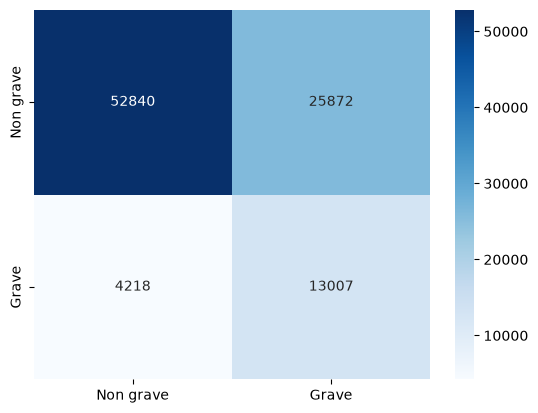

In [19]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non grave', 'Grave'],
    yticklabels=['Non grave', 'Grave']
)  

### Interprétation des résultats

Le modèle CatBoost obtient une accuracy de 69 %. Pour la classe 1, correspondant aux accidents graves, le modèle atteint une precision de 33 %, un recall de 76 % et un F1-score de 0,46.

Le recall de 76 % signifie que le modèle identifie correctement environ trois quarts des accidents graves. En contrepartie, sa precision de 33 % montre qu'une partie importante des prédictions positives correspond à des accidents finalement non graves.

La matrice de confusion montre 13 007 vrais positifs contre 4 218 faux négatifs. Le modèle détecte donc une majorité des accidents graves, mais en identifie également certains comme non graves.

Les performances de CatBoost restent proches de celles du Random Forest optimisé. L'amélioration porte principalement sur le recall de la classe 1, qui atteint 76 %, tandis que le F1-score reste à 0,46.